# Genesis Module 1: The Genetic Algorithm
## Part 3: Evolutionary Computation

**Objective:**
We have the Physics (TTK Calculator). Now we need the Optimizer.
Instead of checking every possible number (Brute Force), we will mimic biology:
1. **Population:** Start with 50 random weapons.
2. **Selection:** Kill the bad ones, keep the top 10%.
3. **Crossover:** Mix the stats of the survivors.
4. **Mutation:** Randomly tweak stats to find new solutions.
5. **Repeat** for 30 Generations.

**The Goal:** Converge on a weapon with **0.00 Error** relative to the target.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TARGET_TTK = 5.0  # We want a 5.0s kill time
ENEMY_HP = 500    # Against a 500 HP enemy
POPULATION_SIZE = 50
GENERATIONS = 30
MUTATION_RATE = 0.1 # 10% chance to mutate a gene

# --- RE-DEFINING PHYSICS (From Notebook 2) ---
class Weapon:
    def __init__(self, damage, fire_rate, mag_size):
        self.damage = int(damage)
        self.fire_rate = round(float(fire_rate), 2)
        self.mag_size = int(mag_size)

def calculate_ttk(weapon):
    shots = np.ceil(ENEMY_HP / weapon.damage)
    reloads = 0
    if shots > weapon.mag_size:
        reloads = np.floor((shots - 1) / weapon.mag_size)

    shooting_time = (shots - 1) / weapon.fire_rate
    return shooting_time + (reloads * 2.0)

def fitness_score(weapon):
    # Lower error is better (0.0 is perfect)
    actual_ttk = calculate_ttk(weapon)
    return abs(TARGET_TTK - actual_ttk)

In [2]:
# --- THE EVOLUTIONARY OPERATORS ---

def create_random_weapon():
    """Genesis: Creates a random weapon from scratch."""
    return Weapon(
        damage=random.randint(10, 100),
        fire_rate=random.uniform(1.0, 10.0),
        mag_size=random.randint(10, 50)
    )

def crossover(parent1, parent2):
    """Mating: Mixes genes from two parents."""
    # Child takes Damage from P1, Fire Rate from P2, Avg Mag Size
    child = Weapon(
        damage=parent1.damage,
        fire_rate=parent2.fire_rate,
        mag_size=int((parent1.mag_size + parent2.mag_size) / 2)
    )
    return child

def mutate(weapon):
    """Mutation: Randomly changes a gene to introduce variety."""
    if random.random() < MUTATION_RATE:
        weapon.damage = max(1, weapon.damage + random.randint(-5, 5))

    if random.random() < MUTATION_RATE:
        weapon.fire_rate = max(0.1, weapon.fire_rate + random.uniform(-0.5, 0.5))

    if random.random() < MUTATION_RATE:
        weapon.mag_size = max(1, weapon.mag_size + random.randint(-5, 5))

    return weapon

🧬 STARTING EVOLUTION (Target: 5.0s TTK)...
Gen 0: Best TTK = 5.18s (Error: 0.1847)
Gen 5: Best TTK = 4.98s (Error: 0.0216)
🚀 CONVERGENCE REACHED at Gen 5!


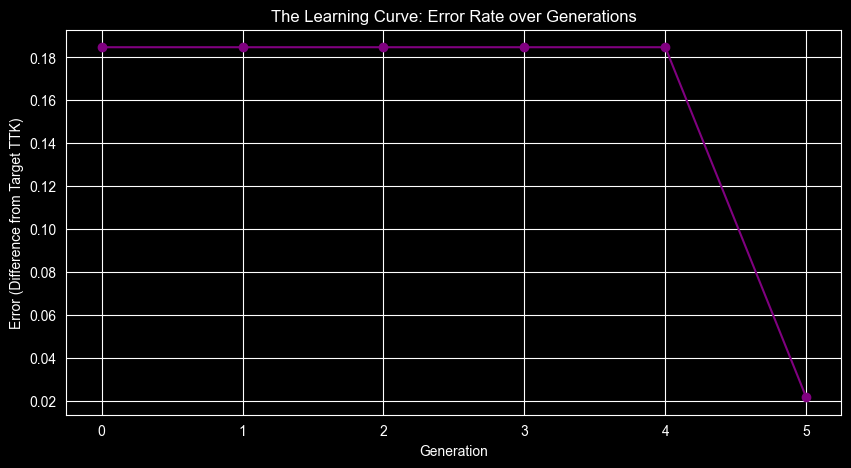


🏆 WINNER: Dmg 24 | Rate 6.715126047492101 | Mag 17


In [3]:
# --- THE MAIN LOOP ---
population = [create_random_weapon() for _ in range(POPULATION_SIZE)]
history = []

print(f"🧬 STARTING EVOLUTION (Target: {TARGET_TTK}s TTK)...")

for gen in range(GENERATIONS):
    # 1. SORT by Fitness (Best first)
    population.sort(key=fitness_score)
    best = population[0]

    # 2. LOG Data
    current_error = fitness_score(best)
    history.append(current_error)

    if gen % 5 == 0:
        print(f"Gen {gen}: Best TTK = {calculate_ttk(best):.2f}s (Error: {current_error:.4f})")

    # 3. STOP EARLY if perfect
    if current_error < 0.05:
        print(f"🚀 CONVERGENCE REACHED at Gen {gen}!")
        break

    # 4. SELECTION (Keep top 10 Elites)
    next_gen = population[:10]

    # 5. REPRODUCTION
    while len(next_gen) < POPULATION_SIZE:
        # Pick 2 random parents from the top 50%
        p1 = random.choice(population[:25])
        p2 = random.choice(population[:25])
        child = crossover(p1, p2)
        child = mutate(child)
        next_gen.append(child)

    population = next_gen

# VISUALIZE THE LEARNING CURVE
plt.figure(figsize=(10, 5))
plt.plot(history, marker='o', linestyle='-', color='purple')
plt.title("The Learning Curve: Error Rate over Generations")
plt.xlabel("Generation")
plt.ylabel("Error (Difference from Target TTK)")
plt.grid(True)
plt.show()

print(f"\n🏆 WINNER: Dmg {best.damage} | Rate {best.fire_rate} | Mag {best.mag_size}")